# **1. Importing required libraries**

In [1]:
#import the required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
%matplotlib inline

# **2. Loading and Understanding the Dataset**

In [2]:
telco_data=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
telco_data.shape

(7043, 21)

In [4]:
telco_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
telco_data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
telco_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
telco_data.duplicated().sum()

np.int64(0)

In [8]:
telco_data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
#Converting TotalCharges from object to float for numerical analysis and model training
telco_data['TotalCharges']=telco_data['TotalCharges'].replace({' ': "0.0"})
telco_data['TotalCharges']=telco_data['TotalCharges'].astype(float)

In [10]:
telco_data.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [11]:
# Checking the distribution of the target variable
(telco_data['Churn'].value_counts() / len(telco_data['Churn']) * 100).round(2)

,count
Churn,
No,73.46
Yes,26.54


**Observations:**

1. customerID is removed as it is not required for modelling
2. Blank values in the TotalCharges column were identified and replaced with 0.0.
3. Class imbalance was observed in the target variable (Churn), with the classes not being equally represented.

# **3. Exploratory Data Analysis (EDA)**

In [12]:
telco_data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

## **Analysis of Numerical Features**

In [13]:
numerical_columns=['tenure','MonthlyCharges','TotalCharges']

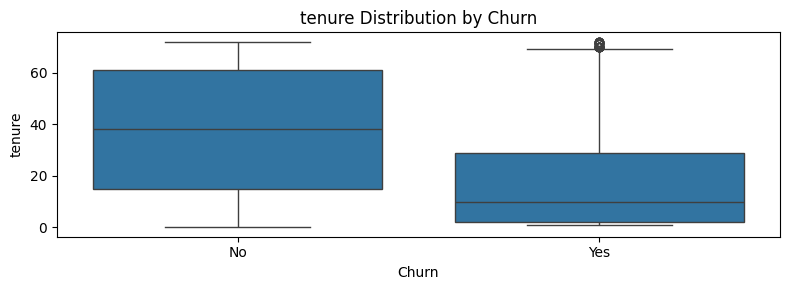

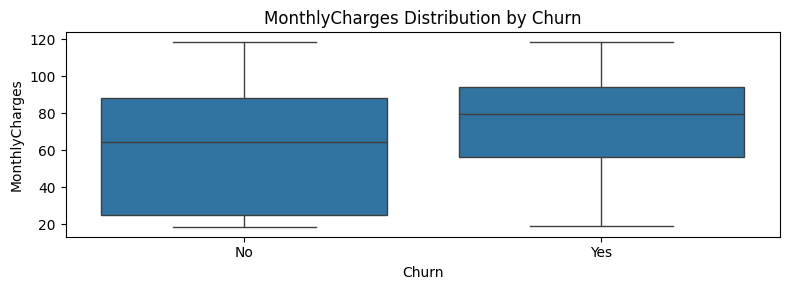

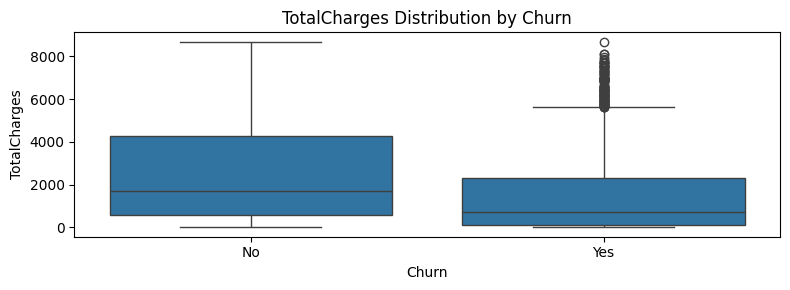

In [14]:
for col in numerical_columns:
  plt.figure(figsize=(8,3))
  sns.boxplot(telco_data, x= "Churn",y=col)
  plt.title(f'{col} Distribution by Churn')
  plt.tight_layout()
  plt.show()

### **Business Insights**
1. **Tenure:** Customers who churned have a substantially lower median
   tenure compared with customers who did not churn, suggesting that
   shorter-tenure customers are more strongly associated with churn.

2. **Monthly Charges:** Churned customers have a higher median monthly
   charge compared with non-churned customers, indicating a potential
   association between higher monthly charges and churn.

3.  **Total Charges:** Churned customers generally have lower total
   charges. This should be interpreted alongside tenure, since total
   charges naturally accumulate over the duration of the customer's
   relationship with the company.

## **Analysis of Categorical columns**

In [15]:
categorical_columns=['gender','SeniorCitizen','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod']

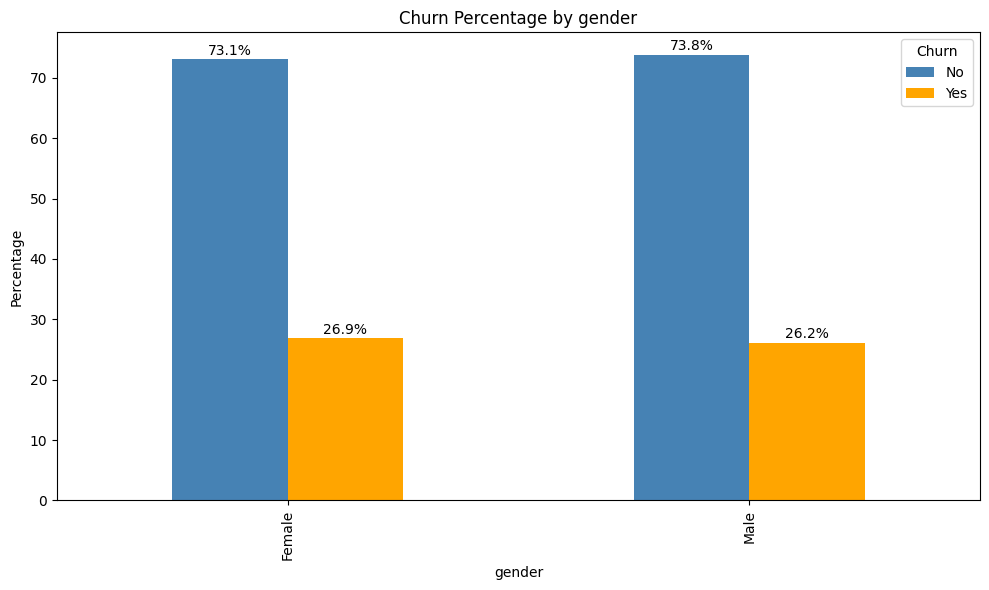

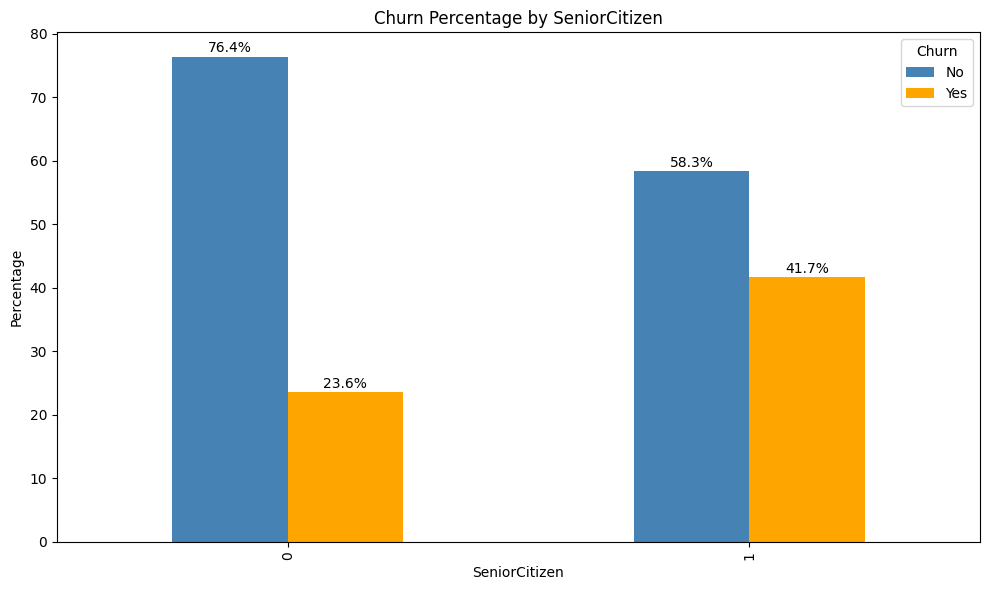

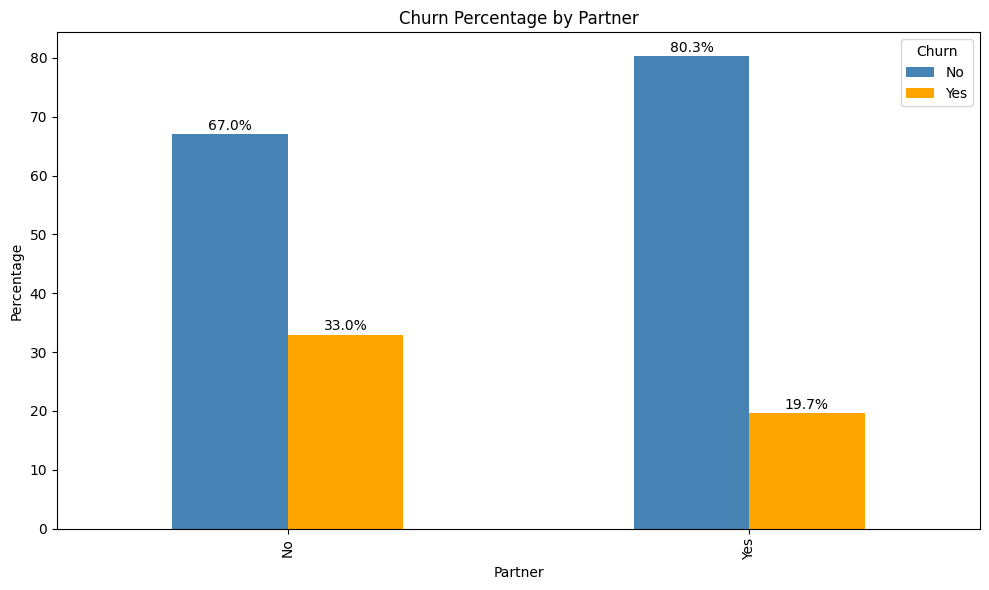

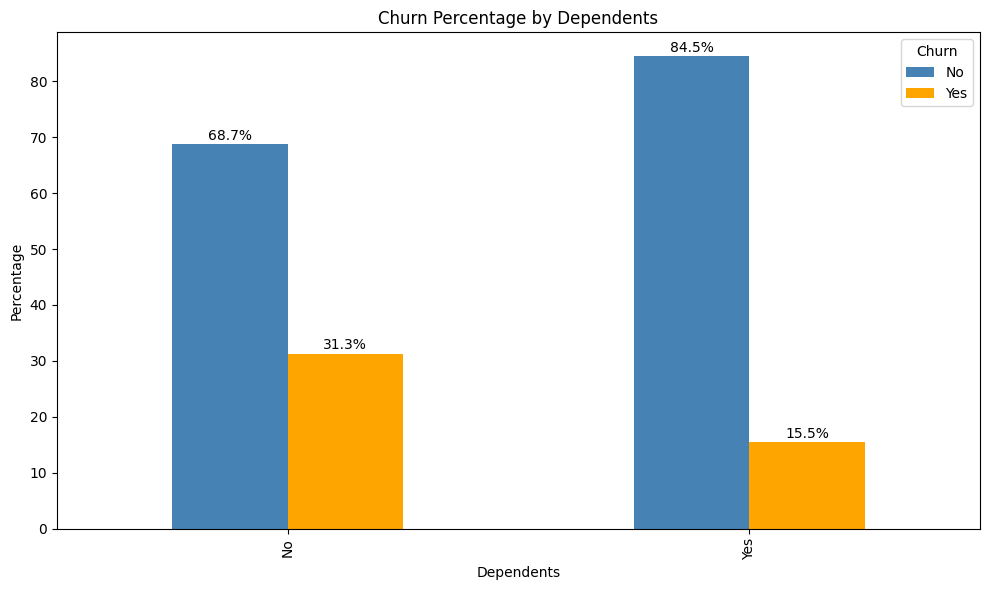

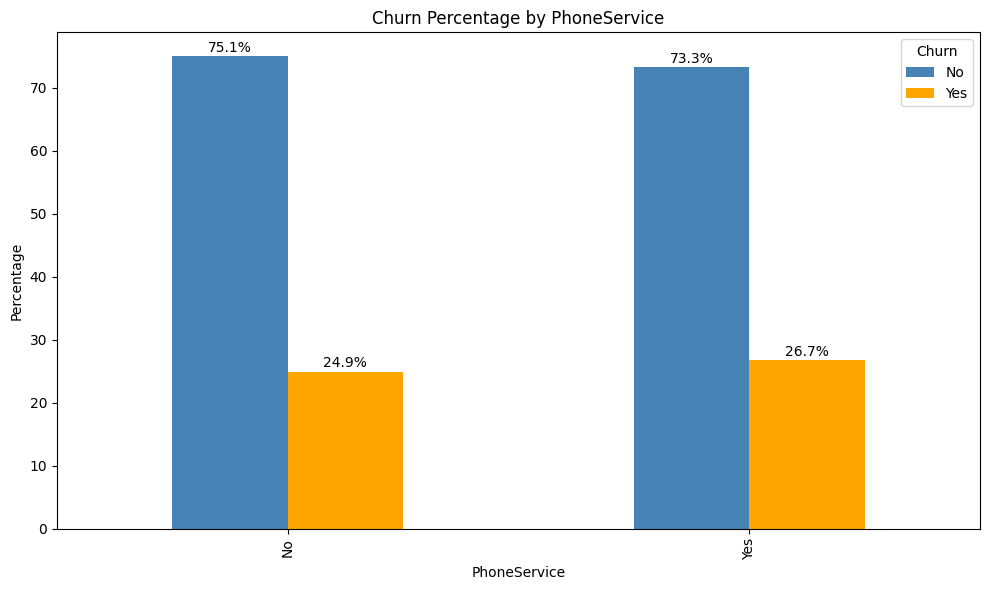

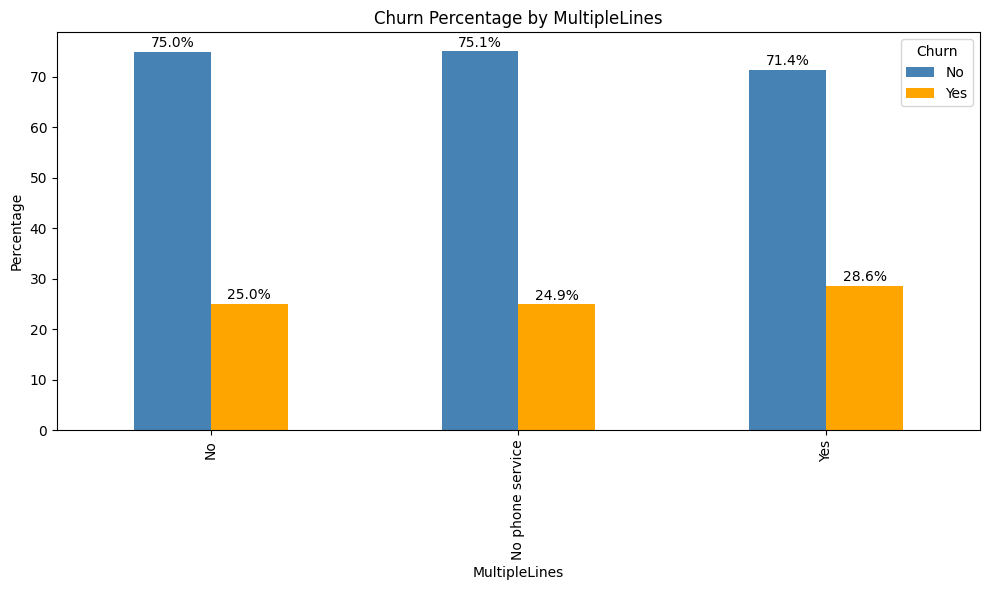

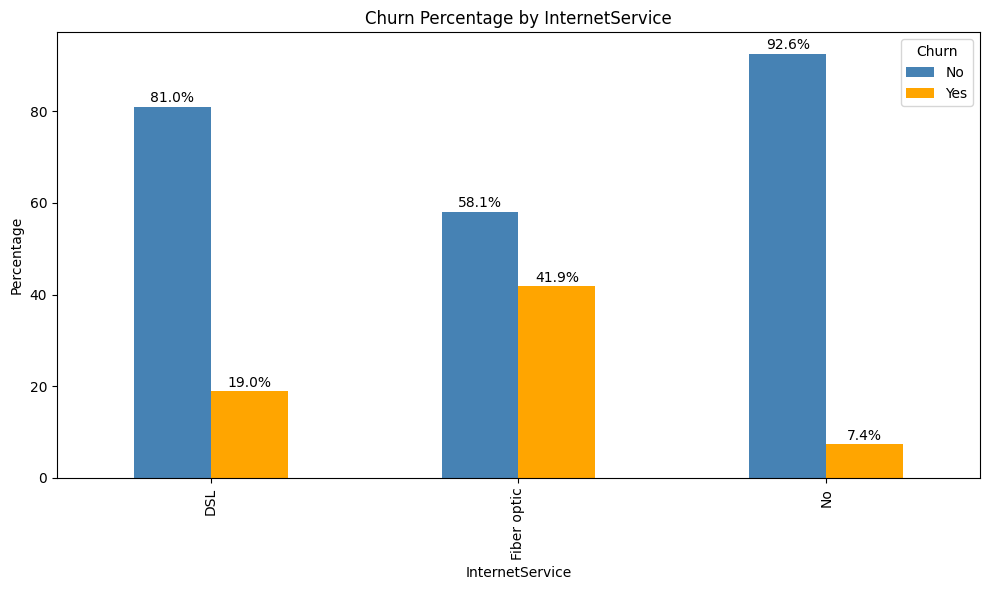

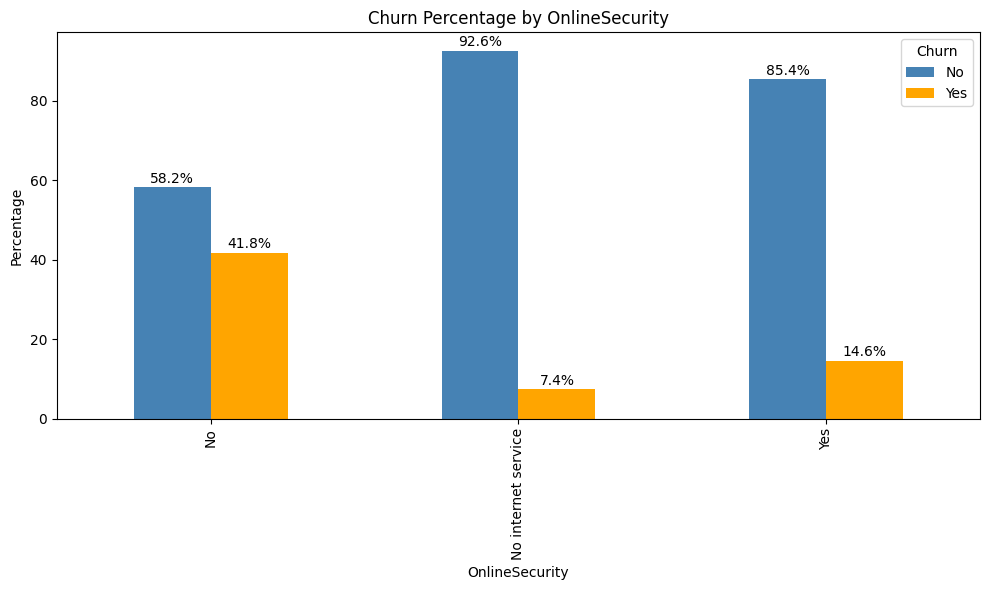

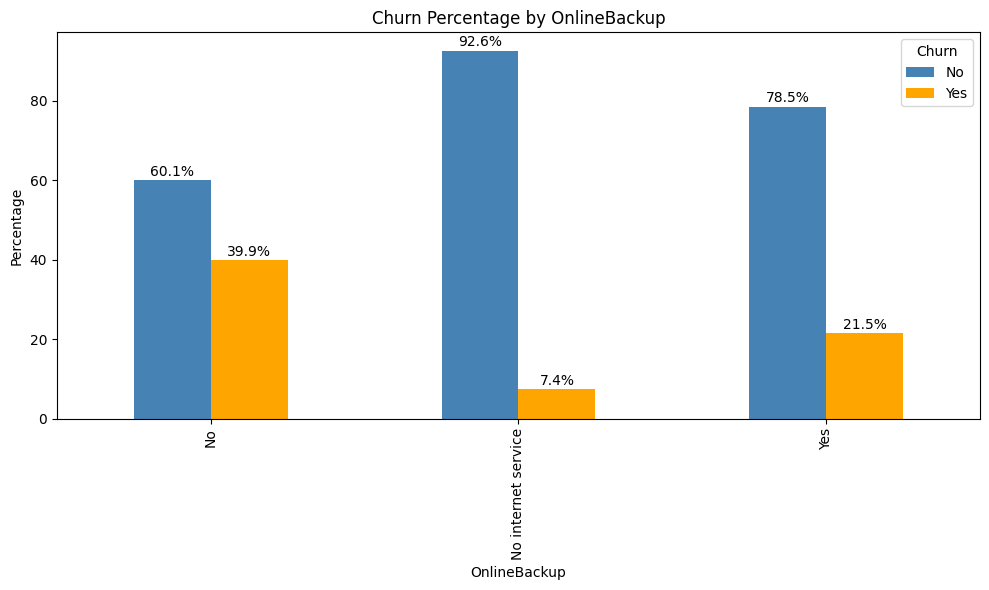

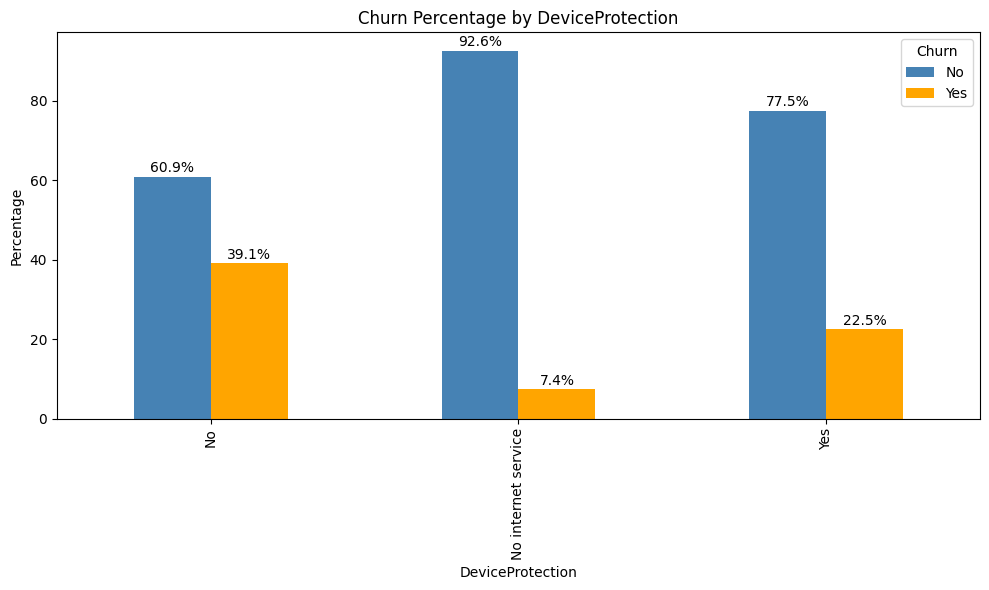

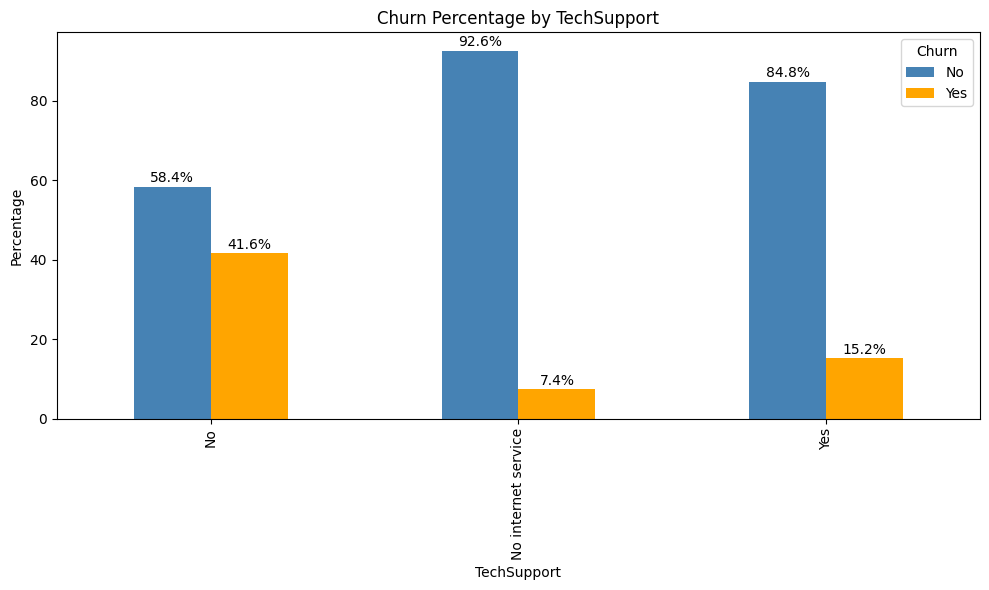

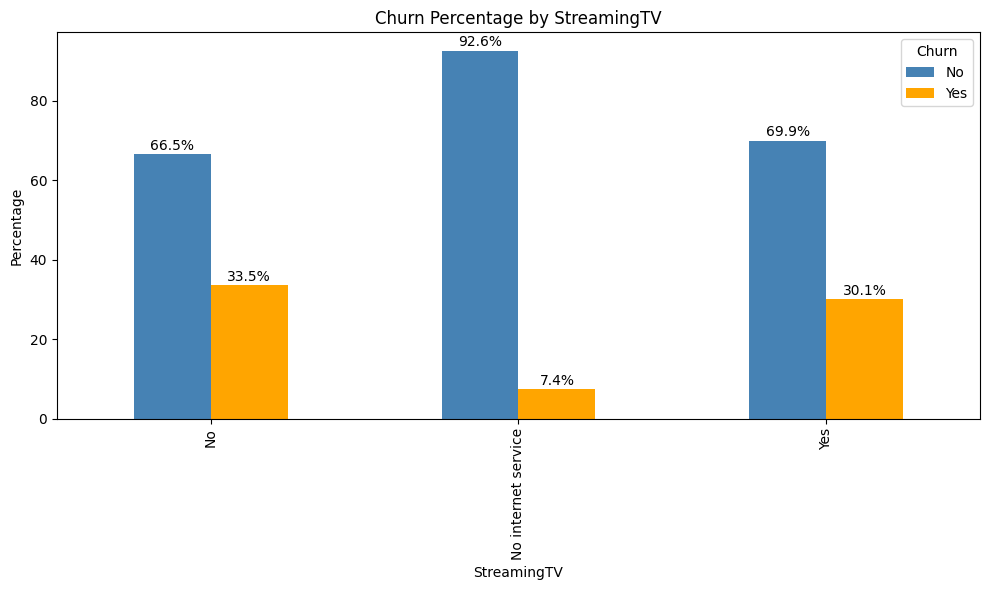

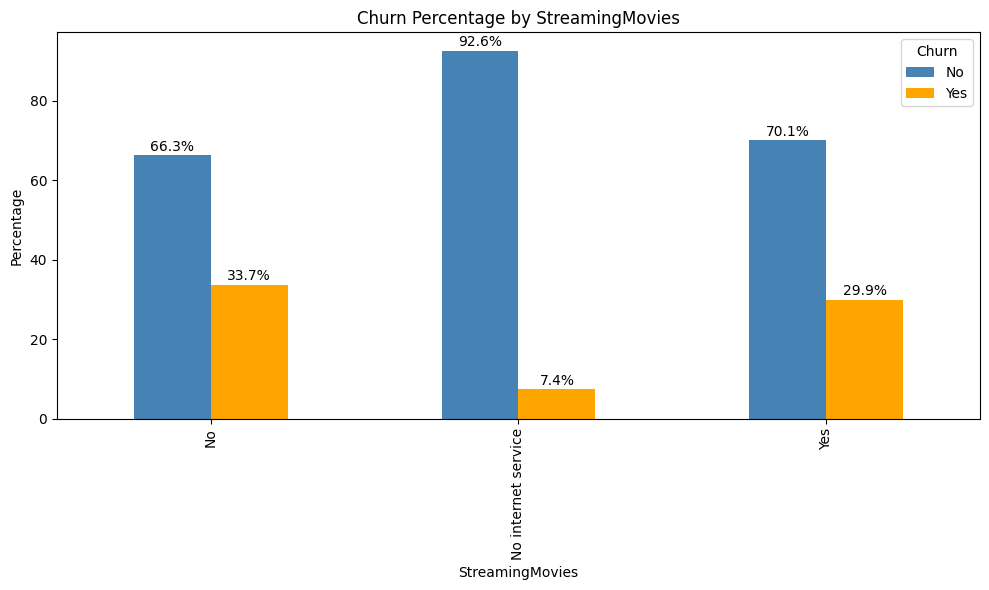

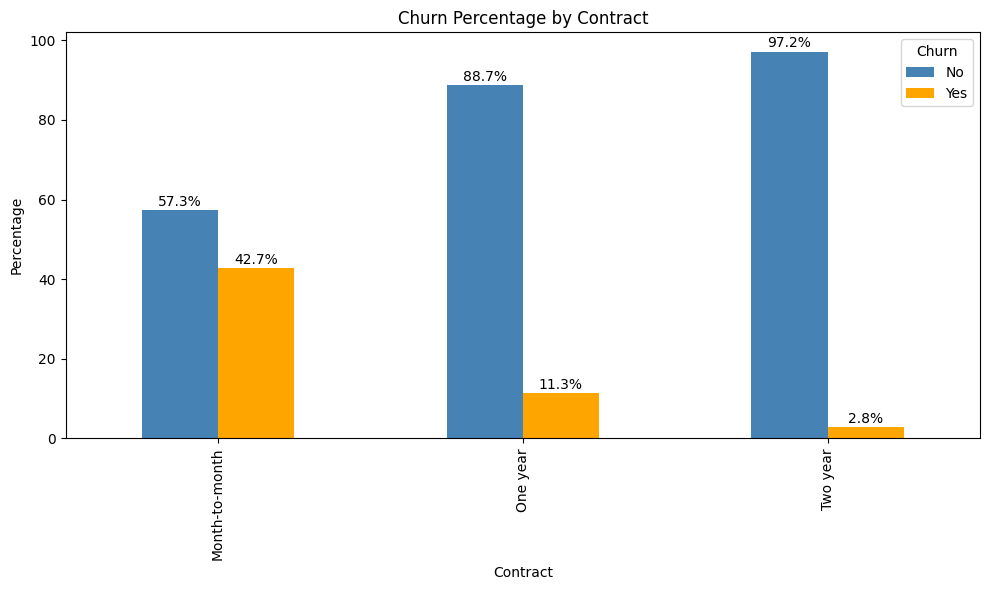

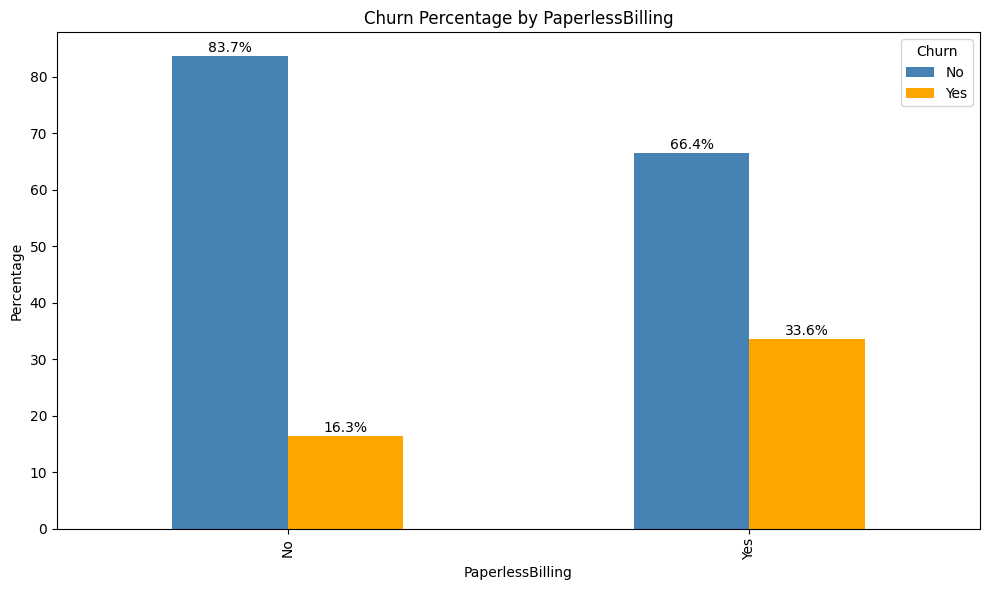

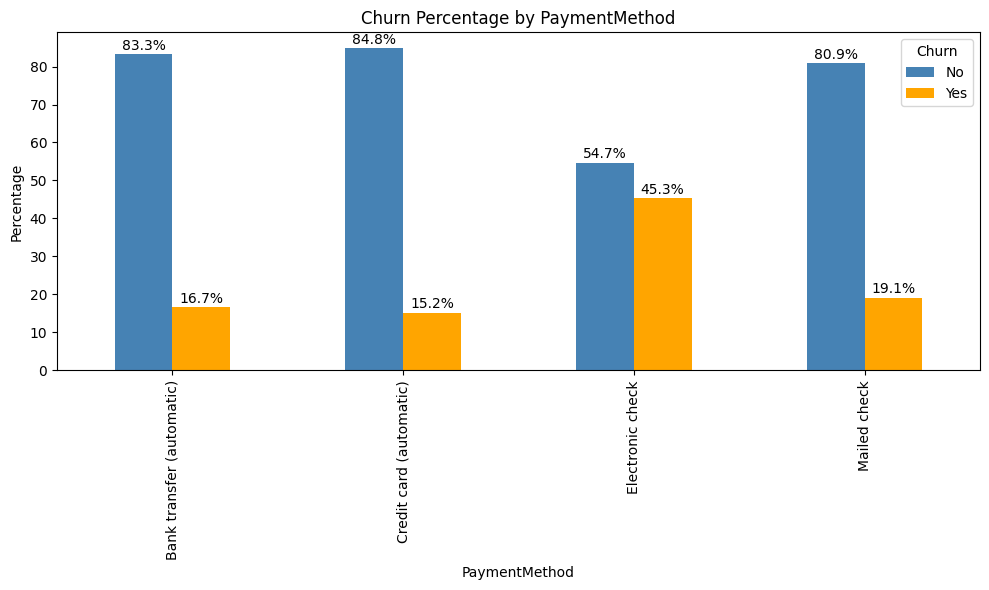

In [16]:
for cols in categorical_columns:
  percentage= pd.crosstab(telco_data[cols],telco_data['Churn'],normalize="index")*100
  ax=percentage.plot(kind='bar',figsize=(10,6),color=['steelblue','orange'])
  for container in ax.containers:
    ax.bar_label(container,fmt="%.1f%%",padding=1)
  plt.title(f'Churn Percentage by {cols}')
  plt.xlabel(cols)
  plt.ylabel("Percentage")
  plt.xticks(rotation=90)
  plt.legend(title="Churn")
  plt.tight_layout()
  plt.show()


### **Business Insights**

1. Gender does not appear to have a significant association with customer churn.
2. Senior-citizen customers exhibit a higher churn rate compared with non-senior customers.
3. Customers without a partner have a considerably higher churn rate than customers with a partner.
4. Customers without dependents show a considerably higher churn rate compared with customers who have dependents.
5. Phone service and multiple-line subscriptions show relatively little difference in churn rates across their respective categories.
6. Fiber optic internet service is associated with a higher churn rate compared with other internet service categories.
7. Customers without additional services such as OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport generally exhibit substantially higher churn rates.
8. StreamingTV and StreamingMovies show relatively modest differences in churn rates between customers who subscribe to these services and those who do not.
9. Customers enrolled in paperless billing exhibit a considerably higher churn rate compared with customers who are not enrolled in paperless billing.
10. Customers using electronic checks exhibit the highest churn rate among the payment methods, while customers using automatic bank transfers and credit cards show comparatively lower churn rates.


# **4. Data Preprocessing**

In [17]:
telco_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [18]:
telco_data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [19]:
telco_data.shape

(7043, 21)

In [20]:
telco_data['Churn']=telco_data['Churn'].replace({'Yes': 1, 'No': 0})

/tmp/ipykernel_9311/4004478218.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  telco_data['Churn']=telco_data['Churn'].replace({'Yes': 1, 'No': 0})


In [21]:
telco_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [22]:
X=telco_data.drop(['customerID', 'Churn'], axis=1)
y=telco_data['Churn']

In [23]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [24]:
telco_data.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [25]:
#Identifying categorical columns

categorical_columns= X_train.select_dtypes(include='object').columns

In [26]:
categorical_columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [27]:
encoder = ColumnTransformer([('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_columns)], remainder='passthrough')

In [28]:
X_train = encoder.fit_transform(X_train)
X_test = encoder.transform(X_test)

# **5. Model Training**

## **a. Applying Logistic Regression**

In [29]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Logistic Regression
model_lr = LogisticRegression()
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## **b. Applying DecisionTreeClassifier**

In [30]:
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.81      0.82      0.81      1035
           1       0.49      0.48      0.48       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



## **c. Applying RandomForestClassifier**

In [31]:
model_rf = RandomForestClassifier(n_estimators=100, criterion='gini', random_state = 100,max_depth=6, min_samples_leaf=8)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1035
           1       0.68      0.45      0.54       374

    accuracy                           0.80      1409
   macro avg       0.75      0.68      0.70      1409
weighted avg       0.78      0.80      0.78      1409



## **d. Applying XGBClassifier**

In [32]:
model_xgb = XGBClassifier(n_estimators=100, random_state=42)
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1035
           1       0.59      0.52      0.55       374

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [33]:
# Since the target variable is imbalanced, we will try class weights and SMOTE to handle the class imbalance.

# **6. Model Training with class weights**

## **a. Applying LogisticRegression**

In [34]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Logistic Regression
model_lr = LogisticRegression(class_weight='balanced')
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



## **b. Applying DecisionTreeClassifier**



In [35]:
model_dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1035
           1       0.49      0.49      0.49       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



## **c. Applying RandomForestClassifier**

In [36]:
model_rf = RandomForestClassifier(n_estimators=100, criterion='gini', random_state = 100,max_depth=6, min_samples_leaf=8)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1035
           1       0.68      0.45      0.54       374

    accuracy                           0.80      1409
   macro avg       0.75      0.68      0.70      1409
weighted avg       0.78      0.80      0.78      1409



# **7. Applying SMOTE to training data**

In [37]:
smote=SMOTE(random_state=42)


## **a. Applying LogisticRegression**

In [38]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_smote_scaled, y_train_smote_scaled = smote.fit_resample(X_train_scaled,y_train)
model_lr_smote = LogisticRegression()
model_lr_smote.fit(X_train_smote_scaled, y_train_smote_scaled)
y_pred_lr_smote = model_lr_smote.predict(X_test_scaled)
print(classification_report(y_test, y_pred_lr_smote))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



## **b. Applying DecisionTreeClassifier**

In [39]:
model_dt_smote = DecisionTreeClassifier(random_state=42)
X_train_smote_dt, y_train_smote_dt = smote.fit_resample(X_train, y_train)
model_dt_smote.fit(X_train_smote_dt, y_train_smote_dt)
y_pred_dt_smote = model_dt_smote.predict(X_test)
print(classification_report(y_test, y_pred_dt_smote))

              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1035
           1       0.48      0.49      0.49       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



## **c. Applying RandomForestClassifier**

In [40]:
model_rf_smote = RandomForestClassifier(n_estimators=100, criterion='gini', random_state = 100,max_depth=6, min_samples_leaf=8)
X_train_smote_rf, y_train_smote_rf = smote.fit_resample(X_train, y_train)
model_rf_smote.fit(X_train_smote_rf, y_train_smote_rf)
y_pred_rf_smote = model_rf_smote.predict(X_test)
print(classification_report(y_test, y_pred_rf_smote))

              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1035
           1       0.56      0.70      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409



## **d. Applying XGBClassifier**

In [41]:
model_xgb_smote = XGBClassifier(n_estimators=100,random_state=42)
X_train_smote_xgb, y_train_smote_xgb = smote.fit_resample(X_train, y_train)
model_xgb_smote.fit(X_train_smote_xgb, y_train_smote_xgb)
y_pred_xgb_smote = model_xgb_smote.predict(X_test)
print(classification_report(y_test, y_pred_xgb_smote))

              precision    recall  f1-score   support

           0       0.84      0.87      0.85      1035
           1       0.60      0.55      0.57       374

    accuracy                           0.78      1409
   macro avg       0.72      0.71      0.71      1409
weighted avg       0.78      0.78      0.78      1409



# **8. Model Selection**

After comparing all the models, **Logistic Regression with SMOTE** was selected for further tuning.
It gave a churn recall of 83% and an F1-score of 64%. The high recall means that the model was able to identify most of the customers who churned.
Therefore, this model will be used for hyperparameter tuning.

# **9. Hyperparamter Tuning**

In [42]:
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=2000))
])

param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear']
}

grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'model__C': 10, 'model__penalty': 'l1', 'model__solver': 'liblinear'}


In [43]:
best_model = grid_search.best_estimator_

y_pred_final = best_model.predict(X_test)

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



# **10. Preparing Data for Model Deployment**

In [64]:
telco_data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [65]:
X_raw = telco_data.drop(['customerID', 'Churn'], axis=1)
y = telco_data['Churn']

In [46]:
X_raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [66]:
X_raw.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


In [67]:
num_cols = X_raw.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_raw.select_dtypes(include=['object']).columns

print("Numerical columns:", list(num_cols))
print("Categorical columns:", list(cat_cols))

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [68]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

In [69]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=2000))
])

In [70]:
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw,y,test_size=0.2,random_state=42,stratify=y)

In [71]:
final_pipeline.fit(X_train_raw, y_train_raw)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('smote', SMOTE(random_state=42)),
                ('model', LogisticRegression(max_iter=2000))])

In [72]:
y_pred_final = final_pipeline.predict(X_test_raw)

In [73]:
from sklearn.metrics import classification_report

print(classification_report(y_test_raw, y_pred_final))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [74]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear']
}

grid_search = GridSearchCV(
    estimator=final_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_search.fit(X_train_raw, y_train_raw)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'Onli...eBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('model',
                                        LogisticRegression(max_iter=2000))]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 1, 10, 100],
                         'model__penalty': ['l1', 'l2'],
                         'model__solver': ['liblinear']},
             scoring='recall')

In [75]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Recall:", grid_search.best_score_*100)

Best Parameters: {'model__C': 100, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV Recall: 80.0


In [76]:
best_model = grid_search.best_estimator_

In [77]:
y_pred_tuned = best_model.predict(X_test_raw)

In [78]:
from sklearn.metrics import classification_report

print(classification_report(y_test_raw, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



After evaluating the different models and approaches, the Logistic Regression model with SMOTE was selected for the final pipeline. The model achieved a churn recall of 80% and an F1-score of 62% on the test data. The complete pipeline integrates preprocessing, SMOTE, and Logistic Regression, making it suitable for deployment.

# **10. Saving the Final ML Pipeline**

In [79]:
import pickle

with open('customer_churn_pipeline.pkl', 'wb') as file:
    pickle.dump(best_model, file)

In [80]:
print("Pipeline saved successfully!")

Pipeline saved successfully!


# **11. Making predictions for new customer**

In [81]:
new_customer = pd.DataFrame({
    'customerID': ['7590-NEW1'],
    'gender': ['Female'],
    'SeniorCitizen': [0],
    'Partner': ['Yes'],
    'Dependents': ['No'],
    'tenure': [8],
    'PhoneService': ['Yes'],
    'MultipleLines': ['No'],
    'InternetService': ['Fiber optic'],
    'OnlineSecurity': ['No'],
    'OnlineBackup': ['No'],
    'DeviceProtection': ['Yes'],
    'TechSupport': ['No'],
    'StreamingTV': ['Yes'],
    'StreamingMovies': ['Yes'],
    'Contract': ['Month-to-month'],
    'PaperlessBilling': ['Yes'],
    'PaymentMethod': ['Electronic check'],
    'MonthlyCharges': [85.50],
    'TotalCharges': [684.00]
})

In [82]:
prediction = best_model.predict(new_customer)

print(prediction)

[1]
